**Data** **Processing**


In [ ]:
import cv2,os,zipfile

data_path='/content/dataset-20250221T190107Z-001.zip'
# Open the zip file
with zipfile.ZipFile(data_path, 'r') as zip_ref:
    # Extract all contents to a temporary directory
    zip_ref.extractall('/tmp/dataset')

# Update data_path to the extracted directory
data_path = '/tmp/dataset/dataset'

# Get a list of all members in the archive
categories = [os.path.basename(name) for name in os.listdir(data_path) if os.path.isdir(os.path.join(data_path,name))]

#categories=os.listdir(data_path)
labels=[i for i in range(len(categories))]

label_dict=dict(zip(categories,labels))

print(label_dict)
print(categories)
print(labels)

{'with mask': 0, 'without mask': 1}
['with mask', 'without mask']
[0, 1]


In [ ]:
img_size=100
data=[]
target=[]

for category in categories:
    folder_path=os.path.join(data_path,category)
    img_names=os.listdir(folder_path)

    for img_name in img_names:
        img_path=os.path.join(folder_path,img_name)
        # Check if the file is an image
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img=cv2.imread(img_path)
            if img is not None:  # Check if image was loaded successfully
                try:
                    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
                    #Coverting the image into gray scale
                    resized=cv2.resize(gray,(img_size,img_size))
                    #resizing the gray scale into 100x100, since we need a fixed common size for all the images in the dataset
                    data.append(resized)
                    target.append(label_dict[category])
                    #appending the image and the label(categorized) into the list (dataset)

                except Exception as e:
                    print('Exception:',e)
                    #if any exception rasied, the exception will be printed here. And pass to the next image
            else:
                print(f"Failed to load image: {img_path}")

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

data=np.array(data)/255.0
data=np.reshape(data,(data.shape[0],img_size,img_size,1))
target=np.array(target)

#from keras.utils import np_utils

#new_target=np_utils.to_categorical(target)

import tensorflow as tf # Import tensorflow

new_target=tf.keras.utils.to_categorical(target) # Use tf.keras.utils.to_categorical
np.save('data.npy', data) # Save data to data.npy
np.save('target.npy', new_target) # Save target to target.npy

CNN

In [ ]:
import numpy as np

data=np.load('data.npy')
target=np.load('target.npy')

#loading the save numpy arrays in the previous code

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Activation,Flatten,Dropout
from keras.layers import Conv2D,MaxPooling2D
from keras.callbacks import ModelCheckpoint

model=Sequential()

model.add(Conv2D(200,(3,3),input_shape=data.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
#The first CNN layer followed by Relu and MaxPooling layers

model.add(Conv2D(100,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
#The second convolution layer followed by Relu and MaxPooling layers

model.add(Flatten())
model.add(Dropout(0.5))
#Flatten layer to stack the output convolutions from second convolution layer
model.add(Dense(50,activation='relu'))
#Dense layer of 64 neurons
model.add(Dense(2,activation='softmax'))
#The Final layer with two outputs for two categories

model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.model_selection import train_test_split

train_data,test_data,train_target,test_target=train_test_split(data,target,test_size=0.1)

In [ ]:
checkpoint = ModelCheckpoint('model-{epoch:03d}.keras',monitor='val_loss',verbose=0,save_best_only=True,mode='auto')
history=model.fit(train_data,train_target,epochs=20,callbacks=[checkpoint],validation_split=0.2)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9595 - loss: 0.0848 - val_accuracy: 0.9073 - val_loss: 0.2594
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9735 - loss: 0.0721 - val_accuracy: 0.9032 - val_loss: 0.2977
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9713 - loss: 0.0766 - val_accuracy: 0.9395 - val_loss: 0.2228
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9851 - loss: 0.0427 - val_accuracy: 0.9274 - val_loss: 0.2880
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9899 - loss: 0.0338 - val_accuracy: 0.9355 - val_loss: 0.2388
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9977 - loss: 0.0165 - val_accuracy: 0.9476 - val_loss: 0.2531
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.9882 - loss: 0.0318 - val_accuracy: 0.9435 - val_loss: 0.2441
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9948 - loss: 0.0244 - val_accuracy: 0.9073 - val_loss:

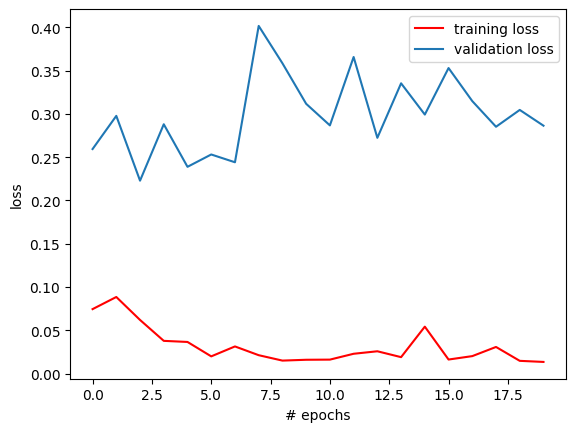

In [ ]:
from matplotlib import pyplot as plt

plt.plot(history.history['loss'],'r',label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('# epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

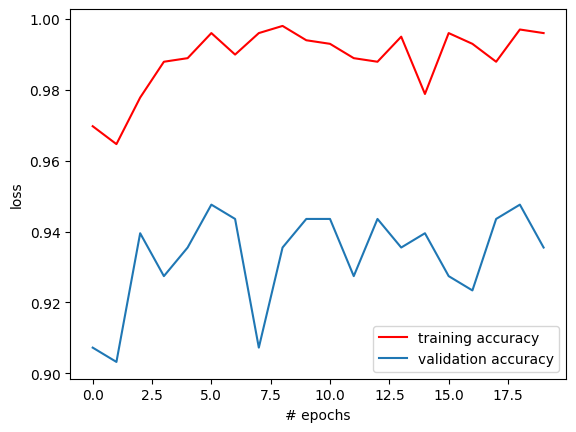

In [ ]:
plt.plot(history.history['accuracy'],'r',label='training accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('# epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
print(model.evaluate(test_data,test_target))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 401ms/step - accuracy: 0.9168 - loss: 0.2370
[0.20412515103816986, 0.9275362491607666]


**Detecting** **Faces**

<IPython.core.display.Javascript object>

Image saved at: webcam_capture.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


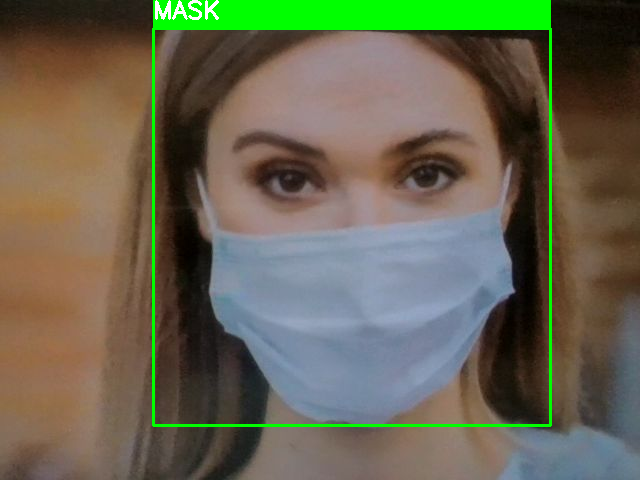

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow  # For displaying images in Colab
from google.colab import output
output.enable_custom_widget_manager()

# Load the trained model
model = load_model('/content/model-016.keras')  # Ensure the correct path

# Load face detector
face_clsfr = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Labels and colors
labels_dict = {0: 'MASK', 1: 'NO MASK'}
color_dict = {0: (0, 255, 0), 1: (0, 0, 255)}

# JavaScript function to capture webcam image
def take_photo(filename='webcam_capture.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Image';
            div.appendChild(capture);
            document.body.appendChild(div);

            const video = document.createElement('video');
            video.style.display = 'block';
            document.body.appendChild(video);

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => capture.onclick = resolve);
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Capture an image using the webcam
image_path = take_photo()
print("Image saved at:", image_path)

# Load the captured image
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_clsfr.detectMultiScale(gray, 1.3, 5)

for x, y, w, h in faces:
    face_img = gray[y:y+h, x:x+w]  # Correct slicing
    resized = cv2.resize(face_img, (100, 100))
    normalized = resized / 255.0
    reshaped = np.reshape(normalized, (1, 100, 100, 1))

    result = model.predict(reshaped)
    label = np.argmax(result, axis=0)[0]

    cv2.rectangle(img, (x, y), (x + w, y + h), color_dict[label], 2)
    cv2.rectangle(img, (x, y - 40), (x + w, y), color_dict[label], -1)
    cv2.putText(img, labels_dict[label], (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

# Display the processed image
cv2_imshow(img)

<IPython.core.display.Javascript object>

Image saved at: webcam_capture.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


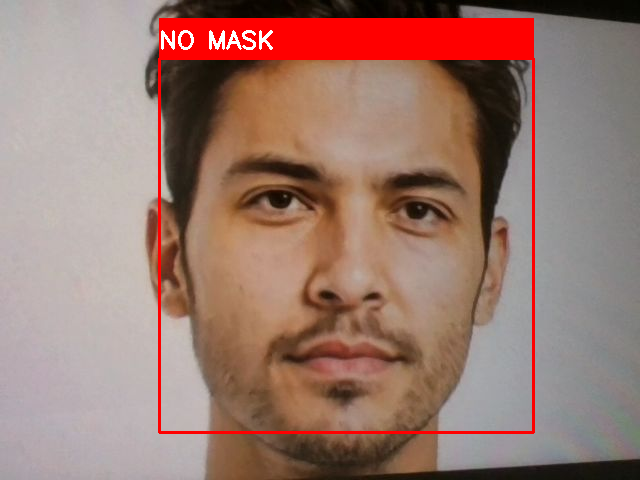

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow  # For displaying images in Colab
from google.colab import output
output.enable_custom_widget_manager()

# Load the trained model
model = load_model('/content/model-016.keras')  # Ensure the correct path

# Load face detector
face_clsfr = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Labels and colors
labels_dict = {0: 'MASK', 1: 'NO MASK'}
color_dict = {0: (0, 255, 0), 1: (0, 0, 255)}

# JavaScript function to capture webcam image
def take_photo(filename='webcam_capture.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Image';
            div.appendChild(capture);
            document.body.appendChild(div);

            const video = document.createElement('video');
            video.style.display = 'block';
            document.body.appendChild(video);

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => capture.onclick = resolve);
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Capture an image using the webcam
image_path = take_photo()
print("Image saved at:", image_path)

# Load the captured image
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_clsfr.detectMultiScale(gray, 1.3, 5)

for x, y, w, h in faces:
    face_img = gray[y:y+h, x:x+w]  # Correct slicing
    resized = cv2.resize(face_img, (100, 100))
    normalized = resized / 255.0
    reshaped = np.reshape(normalized, (1, 100, 100, 1))

    result = model.predict(reshaped)
    label = np.argmax(result, axis=0|1)[0]

    cv2.rectangle(img, (x, y), (x + w, y + h), color_dict[label], 2)
    cv2.rectangle(img, (x, y - 40), (x + w, y), color_dict[label], -1)
    cv2.putText(img, labels_dict[label], (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

# Display the processed image
cv2_imshow(img)